# Bibliotekos

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Duomenų paruošimas

In [5]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [6]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.4, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 3832


In [7]:
purpose_translations = {
    'debt_consolidation': 'Skolų konsolidavimas',
    'credit_card': 'Kredito kortelė',
    'all_other': 'Kita',
    'home_improvement': 'Namų remontas',
    'small_business': 'Smulkus verslas',
    'major_purchase': 'Svarbus pirkinys',
    'educational': 'Edukacija'
}

# Normavimas

In [8]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

numeric_cols = sampled_data.select_dtypes(include=[np.number])
min_max_data = numeric_cols.apply(min_max_normalization)

min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173
1,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767
4,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030


# DBSCAN

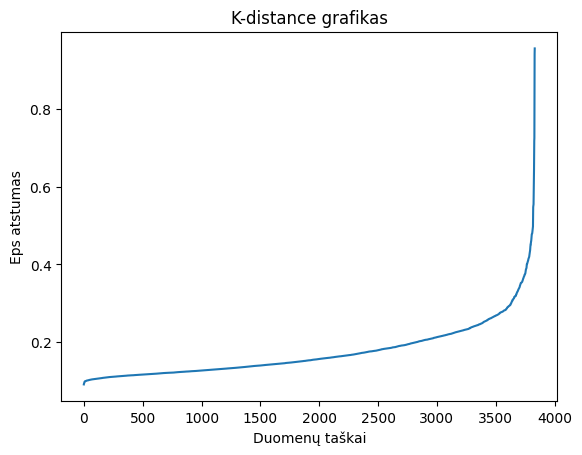

In [10]:
neighbors = NearestNeighbors(n_neighbors=18)
neighbors_fit = neighbors.fit(min_max_data)
distances, indices = neighbors_fit.kneighbors(min_max_data)

distances = np.sort(distances[:, 17], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [15]:
dbscan = DBSCAN(eps=0.3, min_samples=18)
clusters = dbscan.fit_predict(min_max_data)

dbscan_clusters = min_max_data.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3768
-1      64
Name: count, dtype: int64
